In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

In [2]:
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.63k/4.63k [00:00<00:00, 11.6MB/s]

Extracting files...
Path to dataset files: /home/kklmfao/.cache/kagglehub/datasets/yasserh/housing-prices-dataset/versions/1


In [3]:
df = pd.read_csv(path + "/Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
df['prefarea'].value_counts()

prefarea
no     417
yes    128
Name: count, dtype: int64

In [6]:
df = df.replace({'yes': 1, 'no': 0})

In [7]:
df['prefarea'].value_counts()

prefarea
0    417
1    128
Name: count, dtype: int64

In [8]:
features = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']

df[features].shape

(545, 11)

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim

class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

In [29]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

input_scaler = MinMaxScaler()
scaled_features = input_scaler.fit_transform(df[features].values)

output_scaler = MinMaxScaler()
scaled_output = output_scaler.fit_transform(df['price'].values.reshape(-1, 1))

X = torch.tensor(scaled_features, dtype=torch.float32)
y = torch.tensor(scaled_output, dtype=torch.float32).view(-1, 1)

In [30]:
input_dim = len(features)
output_dim = 1

model = LinearRegressionModel(input_dim, output_dim)

model

LinearRegressionModel(
  (linear): Linear(in_features=11, out_features=1, bias=True)
)

In [31]:
# Hyperameters
learning_rate = 0.01
num_epochs = 1000

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

model.train()
# Training loop
for epoch in range(num_epochs):
    y_pred = model(X) # Forward pass
    loss = loss_fn(y_pred, y) # Calculate loss
    
    optimizer.zero_grad() # Clear gradients from last epoch
    loss.backward() # Calculate gradients
    optimizer.step() # Update parameters in model
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

Epoch 0, Loss: 0.15773259103298187
Epoch 10, Loss: 0.06205269321799278
Epoch 20, Loss: 0.038387127220630646
Epoch 30, Loss: 0.025441182777285576
Epoch 40, Loss: 0.017523640766739845
Epoch 50, Loss: 0.014223226346075535
Epoch 60, Loss: 0.012473208829760551
Epoch 70, Loss: 0.011409525759518147
Epoch 80, Loss: 0.010683565400540829
Epoch 90, Loss: 0.01012627873569727
Epoch 100, Loss: 0.009698648005723953
Epoch 110, Loss: 0.009381178766489029
Epoch 120, Loss: 0.009148956276476383
Epoch 130, Loss: 0.00898041296750307
Epoch 140, Loss: 0.008859018795192242
Epoch 150, Loss: 0.008772194385528564
Epoch 160, Loss: 0.008710432797670364
Epoch 170, Loss: 0.008666609413921833
Epoch 180, Loss: 0.008635499514639378
Epoch 190, Loss: 0.008613363839685917
Epoch 200, Loss: 0.00859755091369152
Epoch 210, Loss: 0.008586197160184383
Epoch 220, Loss: 0.00857799593359232
Epoch 230, Loss: 0.008572039194405079
Epoch 240, Loss: 0.008567686192691326
Epoch 250, Loss: 0.008564488030970097
Epoch 260, Loss: 0.0085621243

In [32]:
model.linear.weight, model.linear.bias

(Parameter containing:
 tensor([[0.3126, 0.0556, 0.2613, 0.1187, 0.0404, 0.0275, 0.0331, 0.0777, 0.0762,
          0.0775, 0.0569]], requires_grad=True),
 Parameter containing:
 tensor([-0.0028], requires_grad=True))

In [33]:
model.eval()

y_pred = model(X)

y_pred

tensor([[0.5461],
        [0.7618],
        [0.5068],
        [0.5671],
        [0.4230],
        [0.5777],
        [0.6977],
        [0.6085],
        [0.4945],
        [0.5403],
        [0.5655],
        [0.5682],
        [0.4619],
        [0.3668],
        [0.3756],
        [0.2888],
        [0.5236],
        [0.5408],
        [0.4053],
        [0.4480],
        [0.3193],
        [0.4537],
        [0.3600],
        [0.4117],
        [0.4681],
        [0.5481],
        [0.5529],
        [0.2409],
        [0.5066],
        [0.4725],
        [0.5188],
        [0.4215],
        [0.4261],
        [0.4526],
        [0.3958],
        [0.5085],
        [0.5119],
        [0.5626],
        [0.4274],
        [0.4723],
        [0.3710],
        [0.5001],
        [0.4974],
        [0.4220],
        [0.4723],
        [0.3958],
        [0.4612],
        [0.4957],
        [0.3024],
        [0.4651],
        [0.4729],
        [0.3811],
        [0.4998],
        [0.4688],
        [0.4095],
        [0

In [34]:
y_pred = output_scaler.inverse_transform(y_pred.detach().numpy())

In [35]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(df['price'].values, y_pred)
r2 = r2_score(df['price'].values, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 1141240889344.0
R^2 Score: 0.6731958389282227


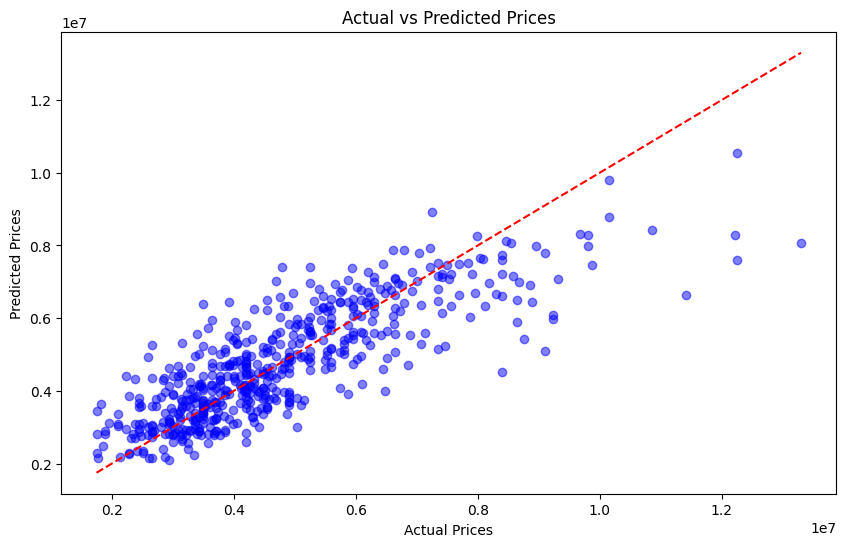

In [36]:
plt.figure(figsize=(10, 6))
plt.scatter(df['price'].values, y_pred, color='blue', alpha=0.5)
plt.plot([df['price'].min(), df['price'].max()], [df['price'].min(), df['price'].max()], color='red', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()